# FDA

In [ ]:
from zellij.core import ArrayVar, FloatVar, Loss, Experiment, Threshold, Minimizer,IThreshold
from zellij.strategies.fractals import ILS, DBA
from zellij.strategies.fractals.sampling import PHS
from zellij.strategies.tools import Hypersphere, DistanceToTheBest, MoveUp
from zellij.utils.converters import FloatMinMax, ArrayDefaultC
from zellij.utils.benchmarks import Rosenbrock

dim = 2
calls = dim * 10**3

fun = Rosenbrock()

lf = Loss(
    objective=[Minimizer("obj")],
    only_score=False,
)(fun)

values = ArrayVar(converter=ArrayDefaultC())
for i in range(dim):
    values.append(
        FloatVar(f"float_{i+1}", fun.lower, fun.upper, converter=FloatMinMax())
    )

sp = Hypersphere(values, save_points=True)

explor = PHS(sp, inflation=1.75)
exploi = ILS(sp, inflation=1.75)
stop1 = Threshold(None, "current_calls", 3)  # set target to None, DBA will automatically asign it.
stop2 = IThreshold(exploi,"step", 1e-16)  # set target to None, DBA will automatically asign it.
stop3 = Threshold(lf, "calls", calls)

ts = MoveUp(sp, 5)

dba = DBA(
    sp, MoveUp(sp, 5), (explor, stop1), (exploi, stop2), scoring=DistanceToTheBest(lf)
)
exp = Experiment(dba, lf, stop3, verbose=True, save="testfda")
exp.run()
print(f"Best solution: f({lf.best_point})={lf.best_score}")

ENDING: |T|calls:2000>=2000
Best solution: f([[3.360597110868106, 11.29887484319707]])=[5.57518748]


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def print_res(path):
    data = pd.read_csv(path, encoding="latin-1")
    argmin = data["obj"].argmin()
    print(f"MIN : {data['obj'].min()}")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect("equal", adjustable="box")

    x = y = np.linspace(fun.lower - 3, fun.upper, 100)
    X, Y = np.meshgrid(x, y)
    Z = (1-X)**2+100*(Y-X**2)**2  # Rosenbrock

    map = ax.contourf(X, Y, Z, cmap="plasma", levels=100)
    fig.colorbar(map, fraction=0.046, pad=0.04)

    xc = data["float_1"]
    yc = data["float_2"]
    xb = data["float_1"].iloc[argmin]
    yb = data["float_2"].iloc[argmin]

    plt.scatter(xc, yc, c="cyan", s=3)
    plt.scatter(xb, yb, c="green")
    plt.scatter(fun.poptimum, fun.poptimum, c="red", alpha=0.5)

    plt.plot()

MIN : 5.575187480706819


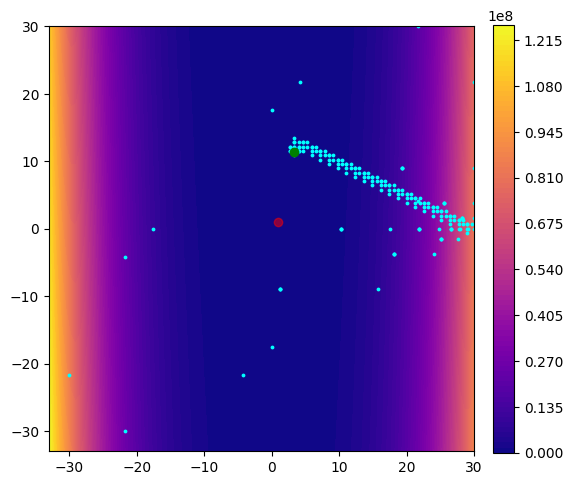

In [36]:
print_res("./testfda/outputs/all_evaluations.csv")